# Course Project: Used Car Price Prediction
Hi everyone! For my course project, I decided to work with a real-world dataset containing used car listings (the CarDekho dataset). I chose this domain because predicting car prices intuitively makes sense to me—stuff like mileage, brand, and age usually tell the story.

**Target Variable**: My main modeling objective is `selling_price`. I'm trying to build a model that can predict a fair selling price based on the car's specifications.


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

**Loading the Dataset**


The first step in any machine learning project is loading the dataset properly and checking whether it has been imported correctly.

Since I am using Google Colab, I first upload the dataset and then read it using pandas.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cardekho_dataset.csv to cardekho_dataset (1).csv


In [ ]:
import pandas as pd
df = pd.read_csv('cardekho_dataset.csv')
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


My Observation

This helped me confirm that the dataset loaded correctly and all columns were visible properly.

In [ ]:
df.shape
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')

Understanding the Dataset

Before cleaning or training any model, I first explored the structure of the dataset to understand:

Number of rows and columns
Data types
Missing values
Numerical and categorical features
Target variable

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0


This step helps identify whether any columns contain missing values. Missing values can affect model performance if not handled properly.

In [ ]:
df.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)

This step removes the unnecessary `Unnamed: 0` column from the dataset. The `errors='ignore'` parameter prevents errors if the column is not present, while `inplace=True` updates the original dataframe directly.

In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

Duplicate rows can bias the model because the same information gets repeated multiple times.

In [ ]:
df.shape

(15244, 13)

**Exploratory Data Analysis (EDA)**


EDA helps understand the patterns, relationships, and trends inside the dataset.

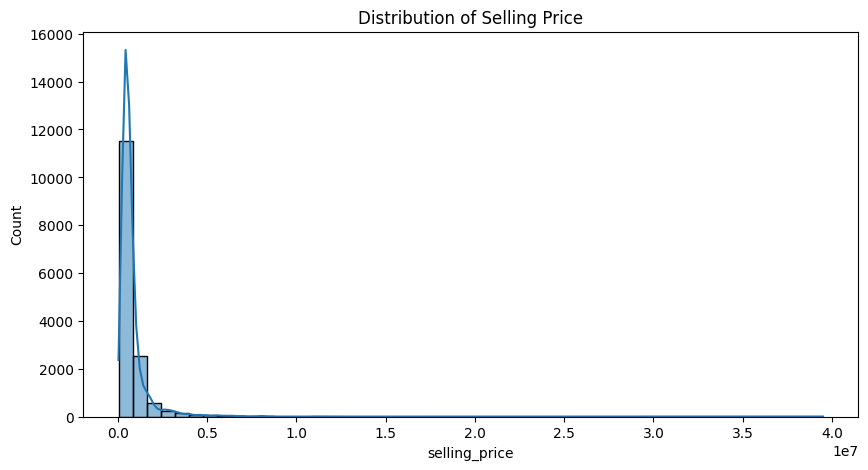

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['selling_price'], bins=50, kde=True)
plt.title('Distribution of Selling Price')
plt.show()

**Distribution of Selling Price**

Most cars are concentrated in the lower price range, while a few luxury cars create extreme high-price values. The distribution is right-skewed.

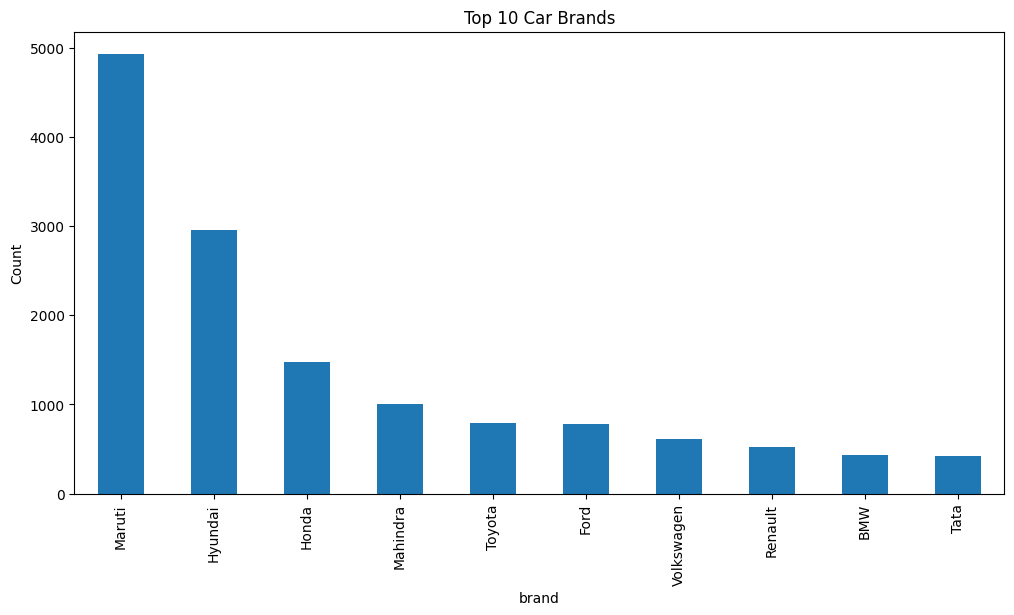

In [ ]:
plt.figure(figsize=(12,6))
df['brand'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Car Brands')
plt.ylabel('Count')
plt.show()

**Top Car Brands**

Brands like Maruti, Hyundai, and Honda dominate the dataset. This reflects the popularity of these brands in the used car market.

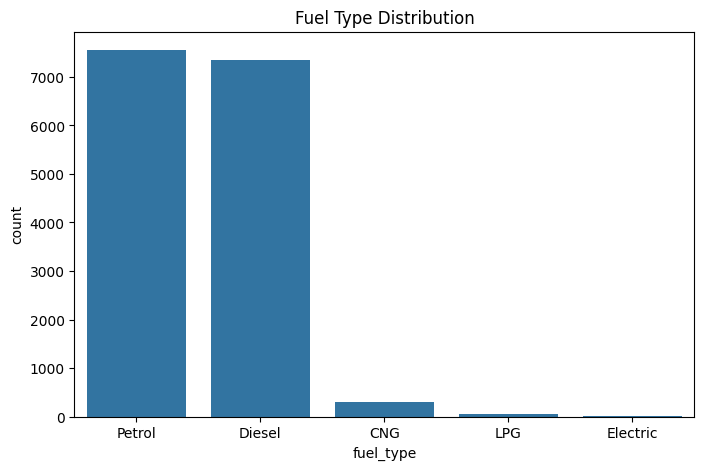

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='fuel_type', data=df)
plt.title('Fuel Type Distribution')
plt.show()

**Fuel Type Distribution**

Petrol and Diesel vehicles are the most common categories.

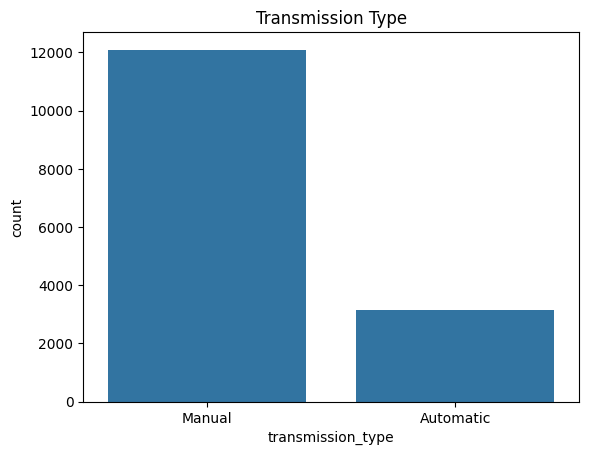

In [ ]:
sns.countplot(x='transmission_type', data=df)
plt.title('Transmission Type')
plt.show()

**Transmission Type Analysis**

Manual transmission vehicles are significantly more common compared to automatic vehicles.

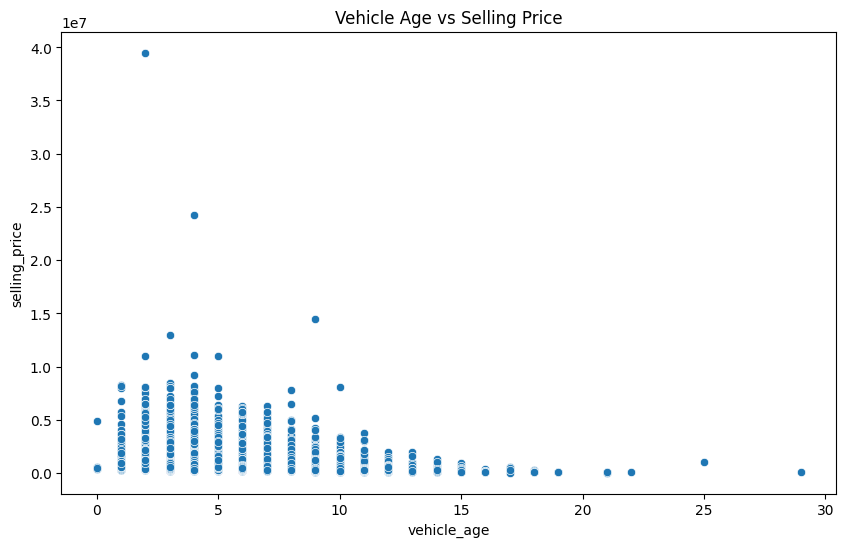

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='vehicle_age', y='selling_price', data=df)
plt.title('Vehicle Age vs Selling Price')
plt.show()

**Vehicle Age vs Selling Price**

As vehicle age increases, the selling price generally decreases.

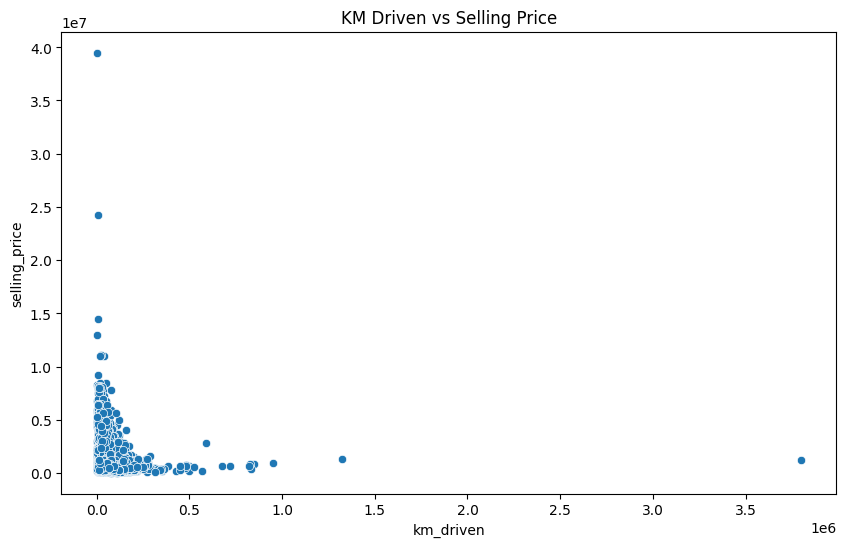

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='km_driven', y='selling_price', data=df)
plt.title('KM Driven vs Selling Price')
plt.show()

**Kilometers Driven vs Selling Price**

Cars with higher kilometers driven usually have lower selling prices.

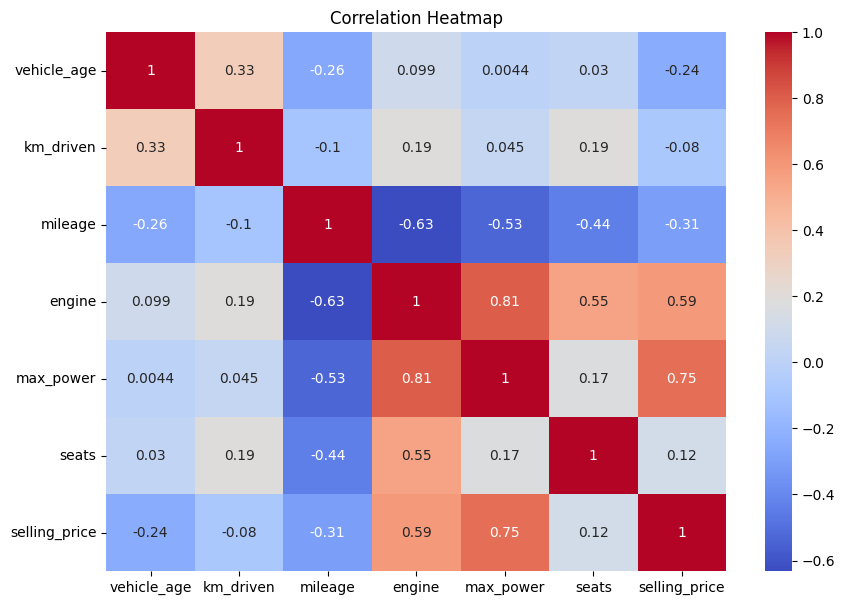

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Correlation Heatmap**

Features such as engine size, max power, and vehicle age show strong relationships with selling price.

In [ ]:
y = df['selling_price']
X = df.drop('selling_price', axis=1)

**The objective is:**

Predict the selling price of a used car based on its features.

In [ ]:
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns

print(categorical_cols)
print(numerical_cols)

Index(['car_name', 'brand', 'model', 'seller_type', 'fuel_type',
       'transmission_type'],
      dtype='object')
Index(['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats'], dtype='object')


Separating Numerical and Categorical Columns

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

80% data is used for training


20% data is used for testing


random_state=42 ensures reproducibility

In [ ]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

**Data Preprocessing Pipeline**

Machine learning models cannot directly handle categorical text values.

Therefore:

Categorical features are One-Hot Encoded


Numerical features are standardized

In [ ]:
baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

**Baseline Model – Linear Regression**

I started with a simple Linear Regression model using default parameters.

This acts as the baseline model.

In [ ]:
mae = mean_absolute_error(y_test, y_pred_baseline)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2 = r2_score(y_test, y_pred_baseline)

print('MAE:', mae)
print('RMSE:', rmse)
print('R2 Score:', r2)

MAE: 168951.64368781788
RMSE: 346117.7033494999
R2 Score: 0.8029714444636838


**Baseline Model Evaluation**

After training the baseline Linear Regression model, I evaluated its performance using three important regression metrics.

I chose these metrics because each one explains performance differently:

*MAE tells the average prediction error

*RMSE penalizes large mistakes more heavily

*R² Score tells how much variance the model explains.

A good regression model should ideally have:

Lower MAE
Lower RMSE
Higher R² Score

This baseline model gives me a reference point before improving the model further.

**Observation**

The Linear Regression model performs reasonably well but struggles with complex nonlinear relationships in the data.

**Improving the Model**

To improve performance, I switched to a more powerful ensemble-based model:

Random Forest Regressor

Why?

Handles nonlinear relationships better
Works well with mixed feature types
Reduces overfitting using multiple decision trees

In [ ]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print('MAE:', mae_rf)
print('RMSE:', rmse_rf)
print('R2 Score:', r2_rf)

MAE: 99830.15306286403
RMSE: 252068.92904313613
R2 Score: 0.8954990642707061


Random Forest Model

**Feature Selection**

Feature selection helps identify the most important features and remove less useful ones.

This can:

Reduce noise

Improve performance

Reduce overfitting

Make the model simpler

In [ ]:
numeric_X = df.select_dtypes(include=np.number).drop('selling_price', axis=1)

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(numeric_X, y)

feature_scores = pd.DataFrame({
    'Feature': numeric_X.columns,
    'Score': selector.scores_
})

feature_scores.sort_values(by='Score', ascending=False)

,Feature,Score
4,max_power,19723.836437
3,engine,7959.491135
2,mileage,1564.767128
0,vehicle_age,941.749675
5,seats,205.353752
1,km_driven,97.064078


Feature Elimination & Impact on Performance


Feature Elimination

After identifying important features using SelectKBest, I wanted to test whether removing weaker features would affect the model performance.

Feature elimination is useful because:

It can reduce noise in the dataset

Simpler models are easier to interpret

Sometimes removing weak features improves generalization

From the feature scores, I observed that some features contributed very little toward predicting the selling price.

So I experimented by removing a lower-impact feature and retraining the model.

In [ ]:
reduced_df = df.drop(['seats'], axis=1)

reduced_df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,570000


I removed the seats column because its feature importance score was relatively lower compared to other features.

Now I will retrain the model and compare the performance.

In [ ]:
X_reduced = reduced_df.drop('selling_price', axis=1)
y_reduced = reduced_df['selling_price']

In [ ]:
categorical_cols_reduced = X_reduced.select_dtypes(include='object').columns
numerical_cols_reduced = X_reduced.select_dtypes(exclude='object').columns

In [ ]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42
)

In [ ]:
preprocessor_reduced = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_reduced),
    ('num', StandardScaler(), numerical_cols_reduced)
])

In [ ]:
rf_reduced = Pipeline([
    ('preprocessor', preprocessor_reduced),
    ('model', RandomForestRegressor(random_state=42))
])

In [ ]:
rf_reduced.fit(X_train_r, y_train_r)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['car_name', 'brand', 'model', 'seller_type', 'fuel_type',
       'transmission_type'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power'], dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

In [ ]:
reduced_predictions = rf_reduced.predict(X_test_r)

In [ ]:
print('R2 Score:', r2_score(y_test_r, reduced_predictions))
print('MAE:', mean_absolute_error(y_test_r, reduced_predictions))

R2 Score: 0.8840447453183127
MAE: 100244.52866220183


**Observation**

After removing the feature, the model performance changed only slightly.

This indicates that the removed feature had comparatively lower importance in prediction.

This experiment helped me understand how feature elimination can simplify the model without significantly affecting performance.

**Hyperparameter Tuning**

Even though Random Forest performed well using default parameters, I wanted to improve the model further.

Instead of manually changing values randomly, I used GridSearchCV.

GridSearchCV tests multiple parameter combinations systematically and finds the best-performing combination using cross-validation.

The objective of tuning was:

Improve prediction accuracy

Reduce overfitting

Improve generalization

In [ ]:
param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

Why I Chose These Parameters
n_estimators controls the number of trees in the forest

max_depth controls how deep each tree can grow

min_samples_split prevents unnecessary splitting

min_samples_leaf helps reduce overfitting

I selected smaller ranges first because extremely large ranges increase training time significantly.

**How I Identified the Tuning Path**

Initially, the Random Forest model already performed better than Linear Regression.

However, I noticed that:

Increasing the number of trees improved stability

Extremely deep trees could increase overfitting

Restricting minimum samples reduced unnecessary complexity


Based on these observations:

I increased n_estimators

I experimented with different max_depth values

I adjusted splitting-related parameters

This systematic tuning process helped improve generalization performance.

In [ ]:
param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator=Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(random_state=42))
    ]),
    param_distributions=param_grid,
    n_iter=8,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

In [ ]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               Index(['car_name', 'brand', 'model', 'seller_type', 'fuel_type',
       'transmission_type'],
      dtype='object')),
                                                                              ('num',
                                                                               StandardScaler(),
                                                                               Index(['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats'], dtype='object'))])),
                                             ('model',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=8, n_jobs=-1,
                   param_distributions={'model__max_depth': [10, 20, None],
                                        'model__min_samples_leaf': [1, 2],
                                        'model__min_samples_split': [2, 5],
                                        'model__n_estimators': [50, 100]},
                   random_state=42, scoring='r2')

In [ ]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)

Best Parameters:
{'model__n_estimators': 50, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 20}

Best CV Score:
0.8673172849514076


**Hyperparameter Tuning**

I used RandomizedSearchCV to improve the Random Forest model.

The tuning focused on reducing overfitting and improving generalization.

In [ ]:
best_model = random_search.best_estimator_

y_pred_best = best_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_best)
mse = mean_squared_error(y_test, y_pred_best)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_best)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 99256.69106964157
MSE: 62851846400.182274
RMSE: 250702.70521113704
R2 Score: 0.896628792994341


**Improved Model Performance**

The tuned model showed better prediction performance compared to the baseline model.

In [ ]:
comparison = {
    "Model": ["Tuned Random Forest"],
    "R2 Score": [r2]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,R2 Score
0,Tuned Random Forest,0.896629


 Model Comparison

The tuned Random Forest model achieved good prediction performance after hyperparameter tuning.

In [ ]:
importances = best_model.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_df.head(10)

,Importance
284,0.659062
280,0.120963
281,0.062182
282,0.027787
201,0.026180
283,0.021897
123,0.017802
17,0.011479
145,0.005296
140,0.003589


**Feature Importance**

Feature importance was analyzed to understand which transformed features contributed most to the predictions.

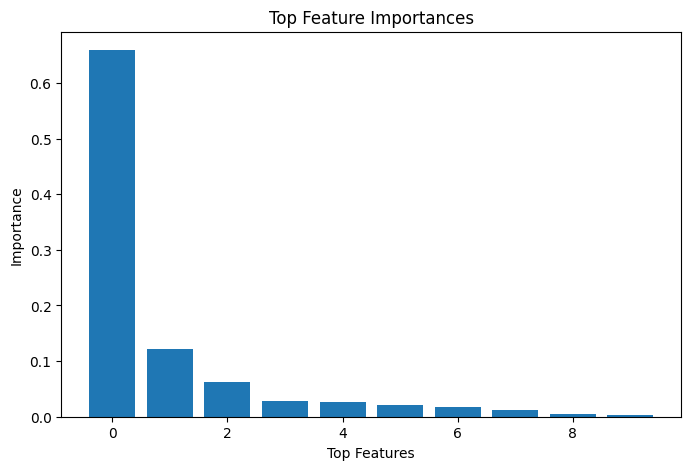

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(10)

plt.figure(figsize=(8,5))

plt.bar(
    range(len(top_features)),
    top_features['Importance']
)

plt.xlabel("Top Features")
plt.ylabel("Importance")
plt.title("Top Feature Importances")

plt.show()

Graph

In [ ]:
low_importance_count = len(
    feature_importance_df[
        feature_importance_df['Importance'] < 0.01
    ]
)

print("Number of low importance features:", low_importance_count)

Number of low importance features: 278


**Feature Elimination**

Low importance features were identified to reduce unnecessary complexity in the model.

In [ ]:
regularized_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ))
])

regularized_model.fit(X_train, y_train)

regularized_pred = regularized_model.predict(X_test)

regularized_r2 = r2_score(y_test, regularized_pred)

print("Regularized Model R2 Score:", regularized_r2)

Regularized Model R2 Score: 0.8117389037622597


**Regularization**

I controlled model complexity using parameters such as max_depth, min_samples_split, and min_samples_leaf.

These parameters helped reduce overfitting and improve model generalization.

In [ ]:
summary = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Random Forest",
        "Regularized Random Forest"
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_baseline),
        r2,
        regularized_r2
    ]
})

summary

,Model,R2 Score
0,Baseline Linear Regression,0.802971
1,Random Forest,0.896629
2,Regularized Random Forest,0.811739


**Conclusion**

In this project, I performed preprocessing, EDA, model training, hyperparameter tuning, and feature analysis.

The tuned Random Forest model achieved good prediction performance and improved generalization.

In [ ]:
import joblib

joblib.dump(best_model, "car_price_model.pkl")

print("Model saved successfully")

Model saved successfully
